# Transportation trips over Geo-taxonomy

Anton Antonov   
June 2026

---

## Introduction

This notebook shows how to map start- and end locations of transportation trips from the Model Management System (MMS) database on a Geo-taxonomy from MMS.

---

## Setup

Packages for data frame manipulation and import:

In [83]:
from GeometricNearestNeighborsProcessor import *
from DataTypeSystem import *

import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import haversine_distances
import matplotlib.pyplot as plt
import seaborn as sns

import json

Using the (newer, recommended) modern `psycopg` (`psycopg3`):

In [84]:
import psycopg

In [85]:
DB_CONFIG = {
    'dbname': 'geo_spatial_pricing_engine',   # Change this
    'user': 'postgres',               # or your username
    'password': '',
    'host': 'localhost',              # or IP / remote host
    'port': '5432'
}

Connect to the database with:

```python
with psycopg.connect(**DB_CONFIG) as conn:
    ...
```

or similar.

Load the chatbook extension:

In [86]:
%load_ext JupyterChatbook

The JupyterChatbook extension is already loaded. To reload it, use:
  %reload_ext JupyterChatbook


---

## Table information

Query to get all tables (excluding system tables):

In [87]:
with psycopg.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT table_schema, table_name, table_type
            FROM information_schema.tables
            WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
            ORDER BY table_schema, table_name;
        """)
        
        tables = cur.fetchall()
        
        print(f"\n📋 Tables in '{DB_CONFIG['dbname']}':\n")
        for schema, table, ttype in tables:
            print(f"{schema:.<15} {table}")


📋 Tables in 'geo_spatial_pricing_engine':

public......... calibrated_value
public......... experiment
public......... experimental_result
public......... geo_taxonomy
public......... model
public......... model_parameter
public......... raw_transportation_trips
public......... tile_data
public......... transportation_trips


---

## Retrieval queries

Get Geo-taxonomy tiles:

In [ ]:
with psycopg.connect(**DB_CONFIG) as conn:
    query="""
    SELECT * FROM geo_taxonomy WHERE geo_taxonomy_id = 'Hextile1deg'
    """
    dfTaxonomy = pd.read_sql_query(query, conn)

dfTaxonomy.shape

Get row transportation trips data:

In [ ]:
with psycopg.connect(**DB_CONFIG) as conn:
    query="""
    SELECT * FROM raw_transportation_trips WHERE raw_transportation_trips_id = 'FAFDerived'
    """
    dfRawTrips = pd.read_sql_query(query, conn)

dfRawTrips.shape

---

## Geo-mapping object

Make a dictionary of tile-ids to tile coordinates:

In [90]:
aTileCenters={rec["tile_id"]: (rec["center_lat"], rec["center_lon"]) for rec in dfTaxonomy.to_dict(orient="records")}
deduce_type(aTileCenters)

Assoc(Atom(<class 'str'>), Pair(Atom(<class 'float'>), Atom(<class 'float'>)), 1043)

In [91]:
gnnObj=GeometricNearestNeighborsProcessor(aTileCenters)

---

## Remapping

For each record of the raw transportation trips find the corresponding start- and end tiles:

In [92]:
lsRows=[
    { 
        "id": rec["id"],
        "start_tile": gnnObj.find_nearest(point=(rec["start_lat"], rec["start_lon"]), n=1).take_value()["ID"][0],
        "end_tile": gnnObj.find_nearest(point=(rec["end_lat"], rec["end_lon"]), n=1).take_value()["ID"][0],
        "distance": rec["distance"]
    } 
    for rec in dfRawTrips.to_dict(orient="records")
]
deduce_type(lsRows)

Vector(Struct([distance, end_tile, id, start_tile], [float, str, int, str]), 4556)

Make a data frame from the records:

In [97]:
dfTileTrips=pd.DataFrame(lsRows)
dfTileTrips.shape

(4556, 4)

----

# Distance correlations

Distance correlations plots in miles:

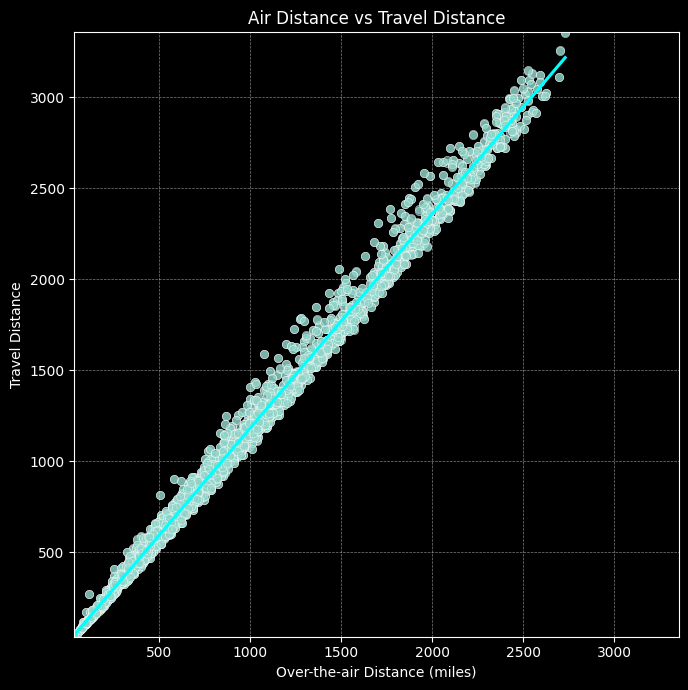

In [94]:
# Copy
df = dfRawTrips.copy()

# Convert to radians
coords_1 = np.radians(df[['start_lat', 'start_lon']].values)
coords_2 = np.radians(df[['end_lat', 'end_lon']].values)

# Compute haversine distances (in kilometers)
# earth_radius_km = 6371.0
earth_radius_miles = 3958.8
haversine_mi = [
    haversine_distances([c1, c2])[0, 1] * earth_radius_miles
    for c1, c2 in zip(coords_1, coords_2)
]

df['air_distance_mi'] = haversine_mi

plt.figure(figsize=(7, 7))
ax = sns.scatterplot(x='air_distance_mi', y='distance', data=df, alpha=0.6)
sns.regplot(x='air_distance_mi', y='distance', data=df, scatter=False, color='cyan', ax=ax)

min_val = min(df['air_distance_mi'].min(), df['distance'].min())
max_val = max(df['air_distance_mi'].max(), df['distance'].max())

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Over-the-air Distance (miles)')
plt.ylabel('Travel Distance')
plt.title('Air Distance vs Travel Distance')
plt.tight_layout()
plt.show()

Correlation value:

In [98]:
corr = df['air_distance_mi'].corr(df['distance'])
corr

np.float64(0.9966273167103427)